# Strand A (temporal), domain level: did tracking change June 2022 → June 2025?

**Estimand at risk:** user-level exposure during June-2022 browsing.
**Threat (T1):** per-domain tracking was measured ~Jan 2025, not June 2022.
**Contribution of this notebook:** the domain-level magnitude and *sign* of
change over the window, on the domains panelists actually visited, measured
with the same instrument (HTTP Archive request maps) at both ends. Matched
domains only, so change reflects site behavior rather than crawl composition.

Prevalence = share of domains where the measure is present; reported
unweighted and weighted by the panel's visits to each domain (which is what
user-level exposure depends on). See `06_temporal_user_exposure` for the same
question at the user level, and `08_instrument_agreement_ha_bl` for how these
request-map measures relate to Blacklight's.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, os.path.abspath(".."))

import config
from utilities import pandas_to_tex, save_mpl_fig

MEASURES = [
    ("ddg_join_ads", "Ad trackers"),
    ("third_party_cookies", "Third-party cookies (header-set)"),
    ("fb_pixel", "Facebook requests"),
    ("google_analytics", "Google Analytics/GTM"),
    ("ddg_known_trackers", "Any known tracker"),
    ("n_third_parties", "Any third party"),
]

Checking that all paths exist:
{'web_mobile': False, 'web_desktop': False, 'web': False, 'yg_profile': False, 'blacklight': False, 'who': False}


In [2]:
m = pd.read_csv(config.FP_HA_DOMAIN_MEASURES)
targets = pd.read_csv(config.FP_HA_TARGETS)
weights = targets.set_index("private_domain")["visits"]
m.groupby(["crawl", "client"]).size()

crawl             client 
blacklight_match  desktop    13071
                  mobile     13030
panel             desktop    13711
                  mobile     13634
recent            desktop    12748
                  mobile     12696
dtype: int64

In [3]:
def prevalence_table(crawl_a, crawl_b, client):
    a = m[(m.crawl == crawl_a) & (m.client == client)].set_index("private_domain")
    b = m[(m.crawl == crawl_b) & (m.client == client)].set_index("private_domain")
    shared = a.index.intersection(b.index)
    a, b = a.loc[shared], b.loc[shared]
    rows = []
    for col, label in MEASURES:
        # third_party_cookies is NaN where the rank-capped cookie query never
        # asked about the domain. `NaN > 0` is False, which silently recodes
        # "never asked" as "asked, found none" -- exactly the artifact
        # 04_classify_trackers was fixed to remove. It matters because coverage
        # is not stable: 45.2% of matched desktop domains were queried in 2022
        # against 36.3% in 2025, and that growing gap alone manufactures a
        # decline. Restrict this measure to domains queried in BOTH crawls, and
        # report its own n so the smaller base is visible.
        keep = pd.Series(True, index=shared)
        if col == "third_party_cookies":
            keep = a["cookies_queried"].astype(bool) & b["cookies_queried"].astype(bool)
        aa, bb = a[keep], b[keep]
        w = weights.reindex(aa.index).fillna(0)
        pa, pb = (aa[col] > 0), (bb[col] > 0)
        vwa, vwb = np.average(pa, weights=w), np.average(pb, weights=w)
        rows.append({
            "measure": label,
            "n_domains": int(keep.sum()),
            "prev_2022_pct": 100 * pa.mean(),
            "prev_2025_pct": 100 * pb.mean(),
            "delta_pp": 100 * (pb.mean() - pa.mean()),
            "vw_prev_2022_pct": 100 * vwa,
            "vw_prev_2025_pct": 100 * vwb,
            "vw_delta_pp": 100 * (vwb - vwa),
        })
    return pd.DataFrame(rows)


drift = pd.concat(
    [prevalence_table("panel", "recent", c).assign(client=c) for c in config.CLIENTS],
    ignore_index=True,
)
drift.round(1)

,measure,n_domains,prev_2022_pct,prev_2025_pct,delta_pp,vw_prev_2022_pct,vw_prev_2025_pct,vw_delta_pp,client
0,Ad trackers,11965,94.0,91.8,-2.2,97.3,94.2,-3.1,desktop
1,Third-party cookies (header-set),3843,87.4,84.3,-3.1,96.4,92.2,-4.2,desktop
2,Facebook requests,11965,56.0,45.8,-10.2,70.2,40.3,-29.9,desktop
3,Google Analytics/GTM,11965,89.3,85.8,-3.5,88.0,84.3,-3.7,desktop
4,Any known tracker,11965,97.9,97.1,-0.8,99.2,97.1,-2.1,desktop
5,Any third party,11965,98.2,97.6,-0.6,99.4,99.0,-0.4,desktop
6,Ad trackers,11944,94.1,91.9,-2.2,97.2,94.4,-2.8,mobile
7,Third-party cookies (header-set),3891,86.6,83.5,-3.1,95.9,91.6,-4.3,mobile
8,Facebook requests,11944,55.5,45.5,-10.0,49.6,40.8,-8.7,mobile
9,Google Analytics/GTM,11944,89.3,85.7,-3.6,87.9,84.1,-3.9,mobile


In [4]:
num_cols = [c for c in drift.columns if c.endswith("_pct") or c.endswith("_pp")]
tex = drift[["client", "measure", "n_domains"] + num_cols].copy()
tex["n_domains"] = tex["n_domains"].map("{:,}".format)
for c in num_cols:
    tex[c] = tex[c].map("{:.1f}".format)
pandas_to_tex(tex, os.path.join(config.TABLES_DIR, "httparchive_drift"))
print("wrote tables/httparchive_drift.tex")

wrote tables/httparchive_drift.tex


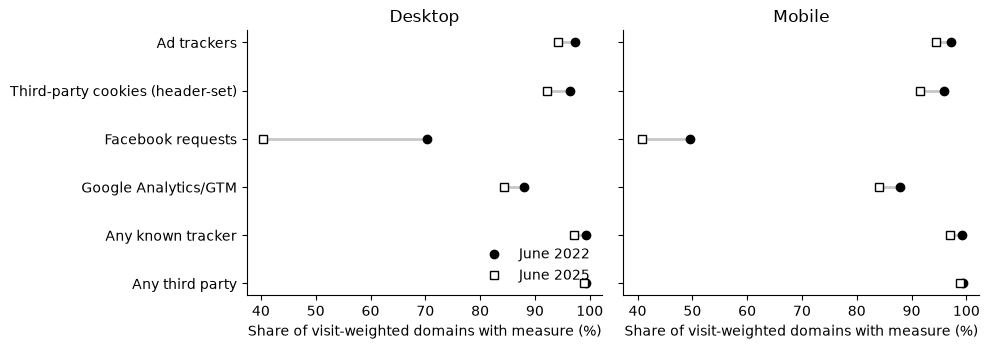

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True, sharex=True)
for ax, client in zip(axes, config.CLIENTS):
    sub = drift[drift.client == client].reset_index(drop=True)
    y = np.arange(len(sub))
    ax.hlines(y, sub["vw_prev_2022_pct"], sub["vw_prev_2025_pct"],
              color="#c7c7c7", lw=2, zorder=1)
    ax.plot(sub["vw_prev_2022_pct"], y, "o", color="#000000",
            label="June 2022", zorder=2)
    ax.plot(sub["vw_prev_2025_pct"], y, "s", mfc="white", mec="#000000",
            label="June 2025", zorder=2)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["measure"])
    ax.set_title(client.capitalize())
    ax.set_xlabel("Share of visit-weighted domains with measure (%)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].invert_yaxis()
axes[0].legend(frameon=False, loc="lower right")
plt.tight_layout()
save_mpl_fig(os.path.join(config.FIGURES_DIR, "ha_drift"))
plt.show()

## Reading the results

`vw_delta_pp` is the signed, visit-weighted change per measure. Positive means
the measure was *more* prevalent in 2025 than in 2022 on the domains the panel
visited — 2025-era scans would overstate June-2022 exposure for that measure;
negative means they understate it. The unweighted and visit-weighted columns
can diverge when change concentrates in heavily visited head domains.